## Main idea and results briefly

I experimented with several modeling approaches, including Ridge Regression, Lasso, ElasticNet, SVR with RBF kernel, neural-network-based models, and HuberRegressor. Among these methods, HuberRegressor performed the best overall, especially after applying robust preprocessing and feature engineering.

The final approach used:

Median imputation for missing values
RobustScaler to reduce the impact of outliers
Target clipping at the 1st and 99th percentiles
Feature engineering on x9, including square-root and cube-root transformations
K-fold validation to evaluate model stability

The best submitted model achieved a Public Score of 0.04674 and a Private Score of 0.03815, outperforming the baseline submission. The highest Private Score among all my submissions was achieved by the HGB model, with a Private Score of 0.11171.



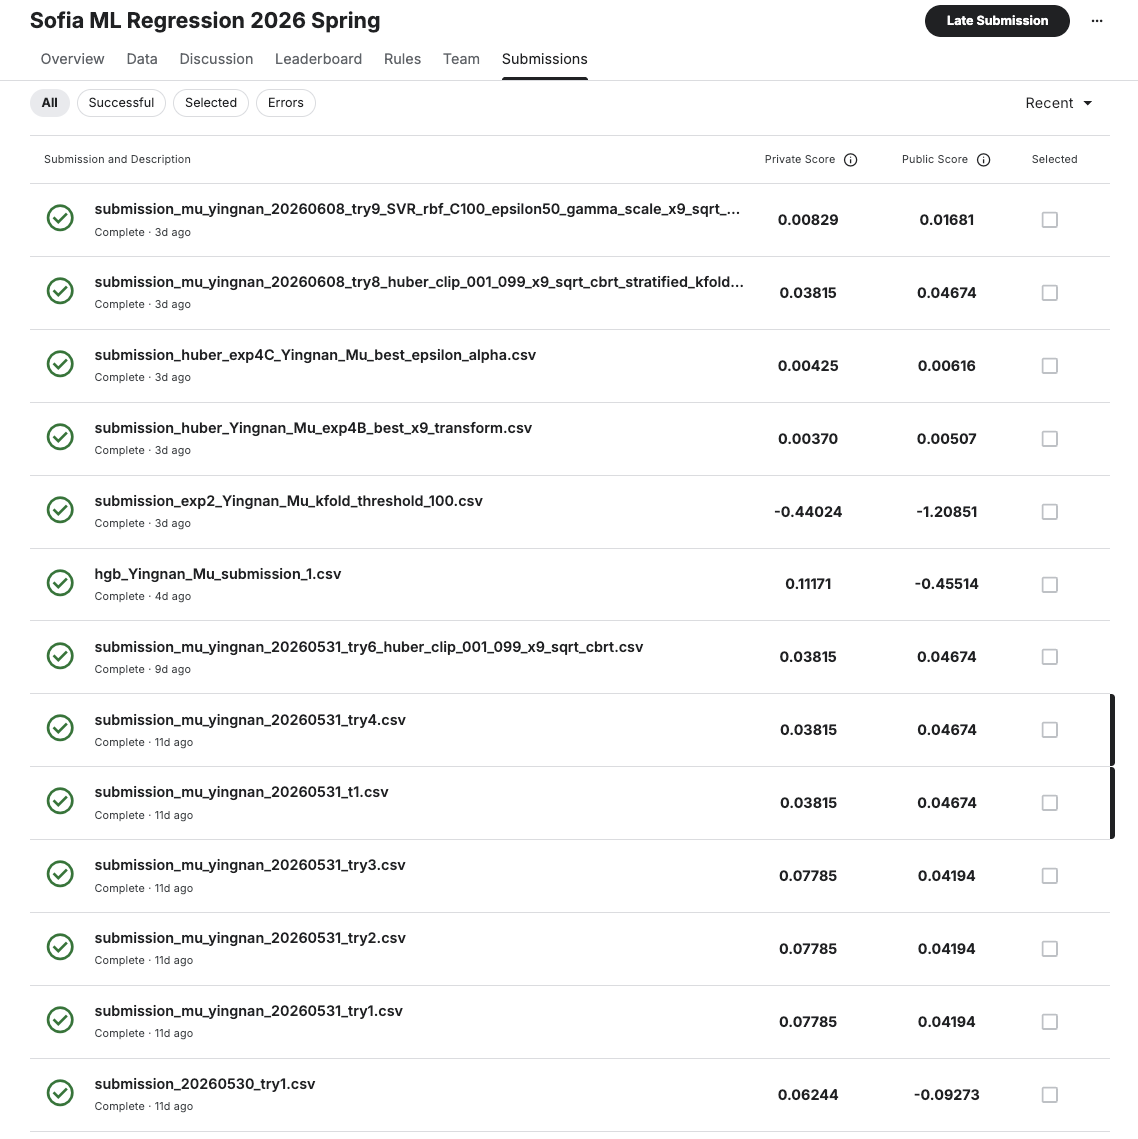

## Part 1: Dataset Overview

In [33]:
# https://www.kaggle.com/competitions/sofia-ml-regression-2026-spring
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from datetime import datetime
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score

In [34]:
train_df = pd.read_csv("/content/spring2026_kaggle_linear_regression_challenge_train.csv")
test_df = pd.read_csv("/content/spring2026_kaggle_linear_regression_challenge_test.csv")
sample_submission = pd.read_csv("/content/spring2026_sampleSubmission.csv")

In [35]:
train_df.head(5)

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,target,Id
0,NaN,4.653737,-7.592557,1.714188,-0.622167,-2.758649,-3.576937,12.825621,-1.077701,-2.990621,-4.889358,7.697097,1.084840,4.670148,1.693087,10.147519,1
1,16.366673,-5.129070,-4.056004,-1.587978,7.676221,16.847336,-0.598568,-8.814040,-5.749997,4.542493,10.320050,7.853915,-1.975601,2.626949,0.458565,40.589306,2
2,1.671239,10.997672,1.770459,1.324817,0.842158,4.314447,3.316170,-15.286950,-2.229412,-3.284181,-8.870790,-3.978508,4.437812,-9.797043,3.805246,-29.214668,3
3,-12.860650,-4.226342,1.288700,1.143941,8.863173,11.838897,-1.831860,-4.850510,5.983591,-1.335703,-17.712846,-16.387132,-2.729443,5.625468,0.559720,-21.157257,4
4,5.276754,-5.392047,1.255338,1.220763,-3.855019,6.816328,-3.477110,-3.808780,-2.662270,-8.349453,6.761591,-6.787475,0.037089,5.439740,1.754827,-23.800982,5


In [36]:
test_df.head(5)

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,Id
0,2.328677,-13.124887,5.942170,1.835397,-24.313437,-19.432058,0.671548,-3.317686,-0.117173,-5.956024,12.210401,11.246734,0.196016,12.754948,1.837269,0
1,5.084936,-1.242914,-3.351731,-0.155560,-21.027248,-21.594852,NaN,-10.462068,2.788057,-6.322131,-5.250770,18.786611,-1.057588,NaN,NaN,6
2,-1.569973,-11.989541,-2.684508,1.639759,-21.525546,6.482782,1.248830,-6.233198,-10.084921,0.503614,-7.351982,3.364457,0.064869,18.124432,-0.940646,7
3,-7.821665,2.262508,1.741962,2.652289,10.407001,5.325486,7.686760,-12.471255,-4.461678,-6.469431,-5.412491,-19.906638,1.885479,-2.514492,-5.780135,8
4,9.980589,2.768668,-3.253775,2.158787,5.343083,22.917654,0.962534,-12.845845,-9.541650,11.526917,23.933020,-2.595816,-1.137512,16.536519,-4.350589,12


In [37]:
X_train = train_df.drop(columns=["Id", "target"])
y_train = train_df["target"]

X_test = test_df.drop(columns=["Id"])

## Part 2: EDA

X_train shape: (2500, 15)


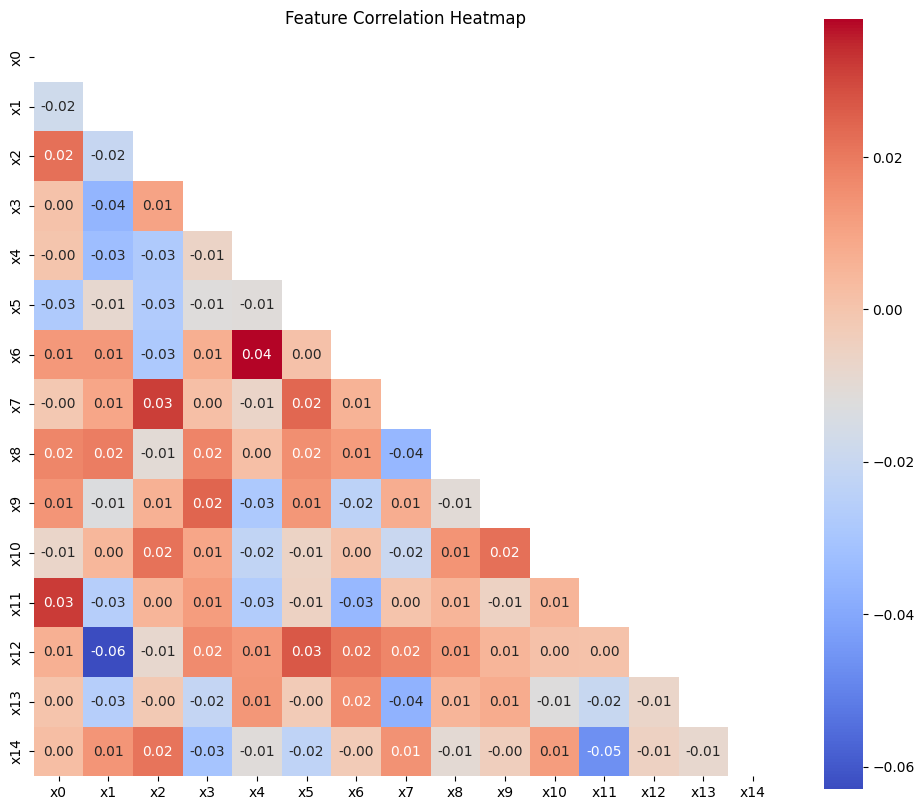

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Check feature shape
print("X_train shape:", X_train.shape)

# Compute correlation matrix
corr_matrix = X_train.corr()

# Create mask to hide upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title("Feature Correlation Heatmap")
plt.show()

### The correlation heatmap shows that most features have very weak pairwise correlations, with values close to 0. This means there is no strong multicollinearity among the input features. However, it also suggests that the dataset may not contain obvious linear feature relationships, which motivated me to test both linear and non-linear regression models.

In [39]:
train_corr = X_train.copy()
train_corr["target"] = y_train

target_corr = train_corr.corr()["target"].drop("target").sort_values(
    key=abs,
    ascending=False
)

print(target_corr)

x9     0.232323
x8    -0.047537
x4     0.040760
x6    -0.040455
x11    0.027480
x5    -0.026242
x10   -0.023372
x2    -0.022743
x7     0.020401
x12    0.014869
x1     0.004935
x0     0.003338
x14   -0.003132
x13    0.002873
x3    -0.001986
Name: target, dtype: float64


### Among all features, x9 has the highest correlation with the target, with a correlation value of 0.2323. All other features have much weaker correlations, mostly close to 0. This suggests that x9 may be the most informative feature in the dataset, which motivated me to perform additional feature engineering on x9, such as square-root and cube-root transformations.

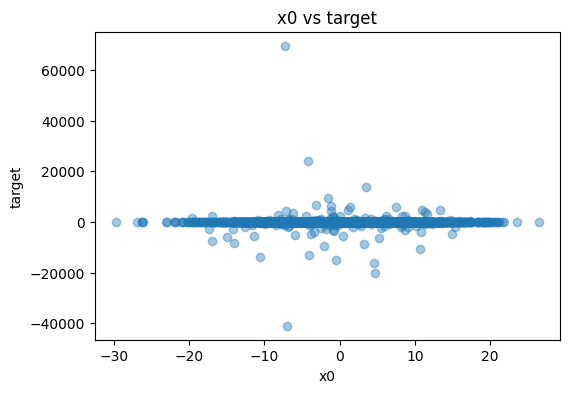

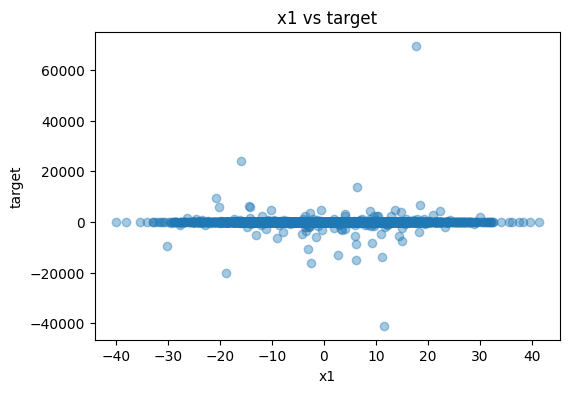

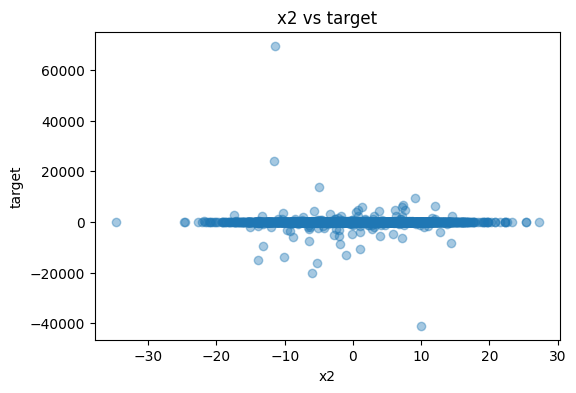

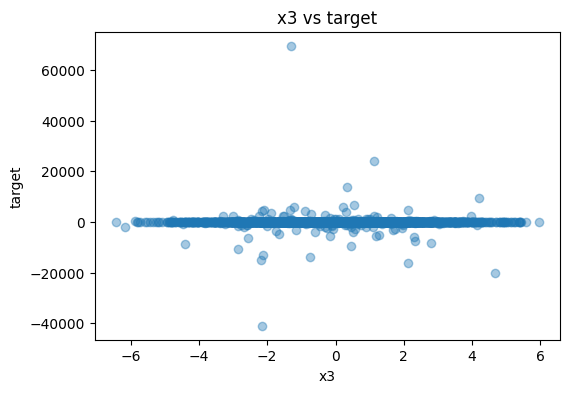

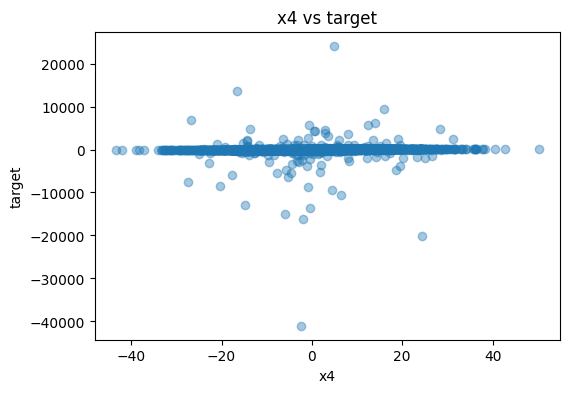

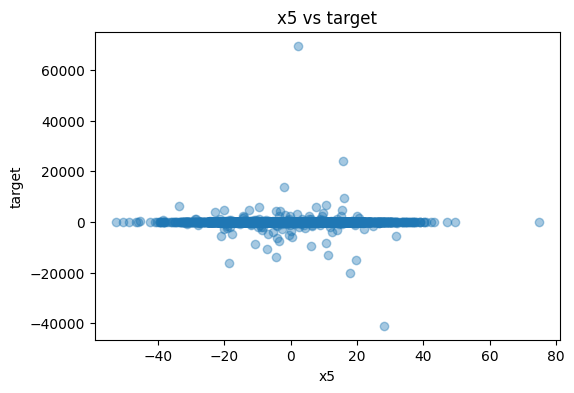

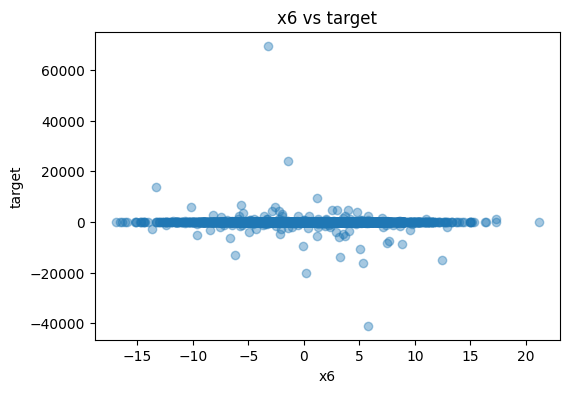

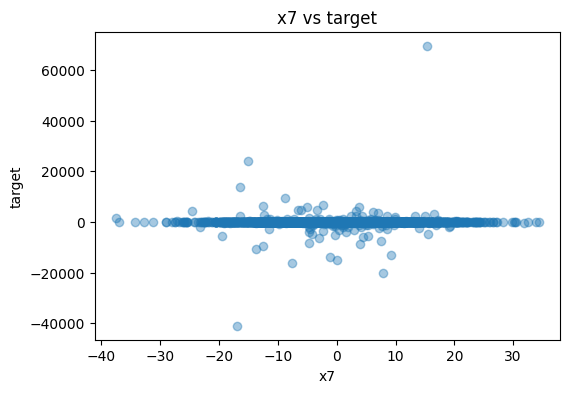

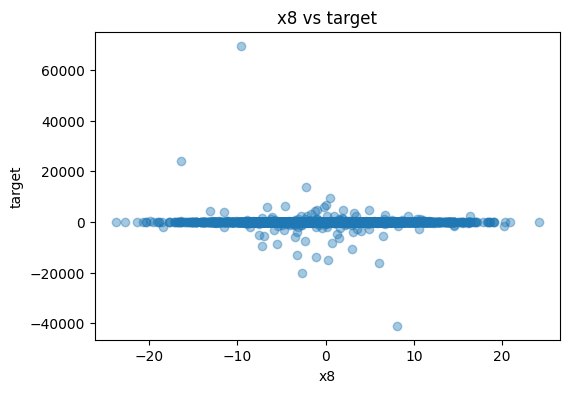

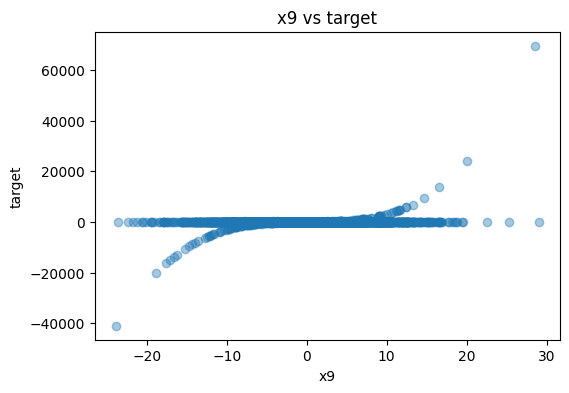

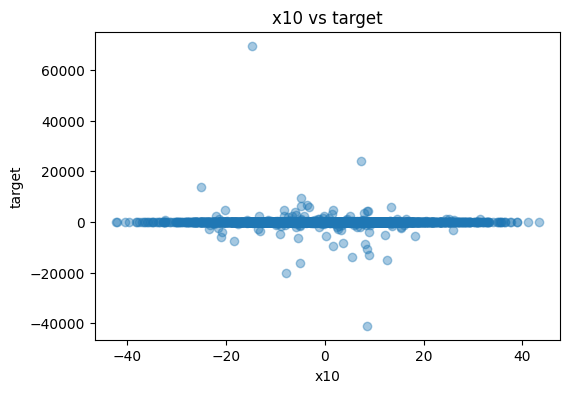

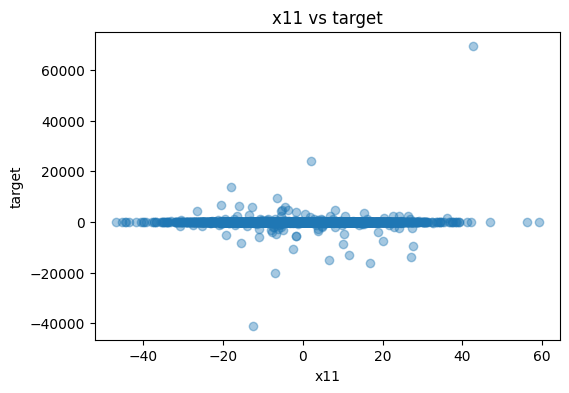

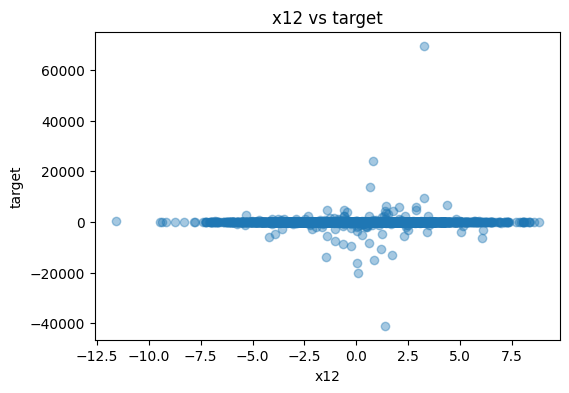

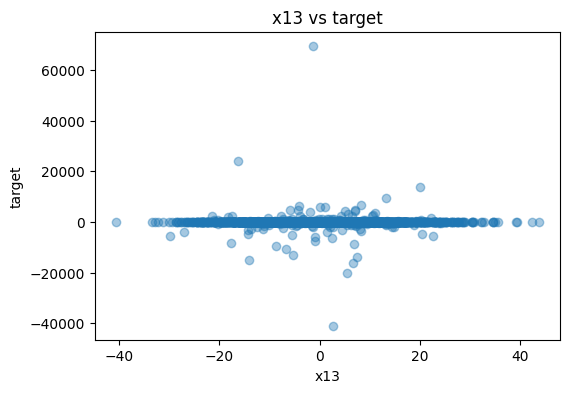

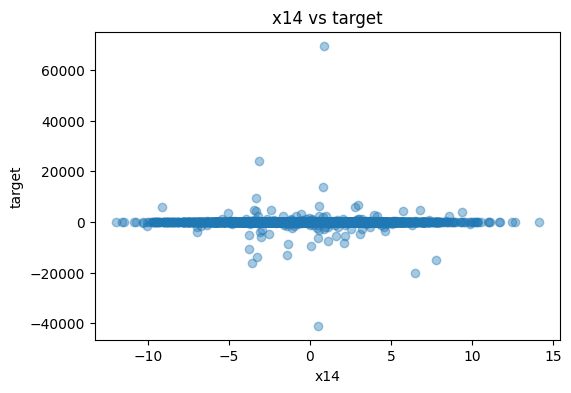

In [40]:
import matplotlib.pyplot as plt

for col in X_train.columns:
    plt.figure(figsize=(6, 4))
    plt.scatter(X_train[col], y_train, alpha=0.4)
    plt.xlabel(col)
    plt.ylabel("target")
    plt.title(f"{col} vs target")
    plt.show()

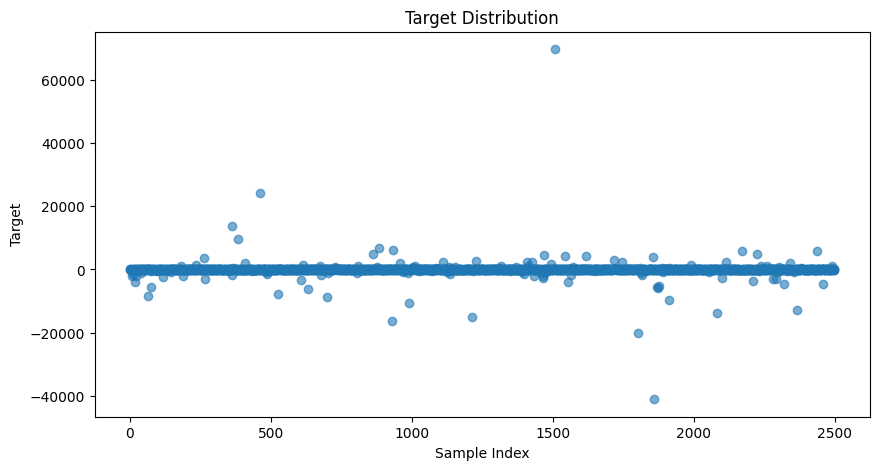

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.scatter(range(len(y_train)), y_train, alpha=0.6)

plt.title("Target Distribution")
plt.xlabel("Sample Index")
plt.ylabel("Target")
plt.show()

Target basic statistics:
count     2500.000000
mean       -22.043467
std       1978.177302
min     -41008.015927
25%        -43.166743
50%         -0.769750
75%         42.000951
max      69628.199874
Name: target, dtype: float64

Skewness: 13.587995421968362
Kurtosis: 707.8060354831437


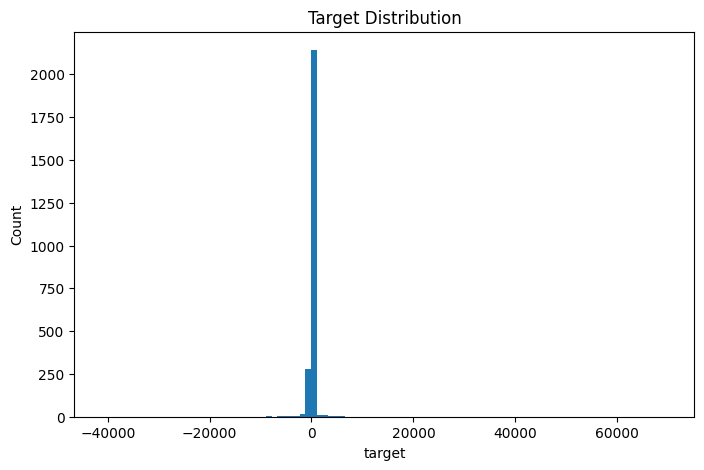

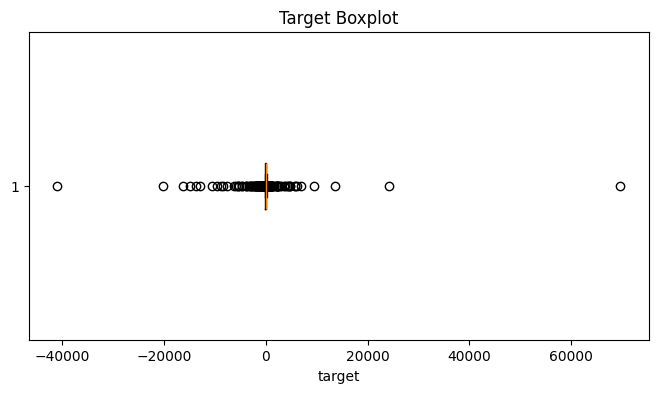

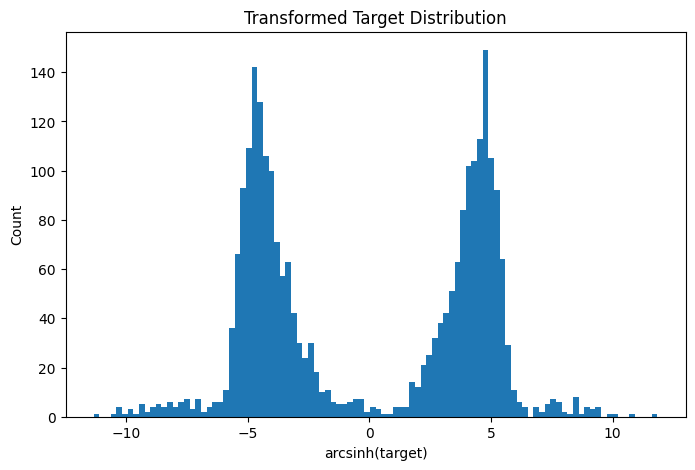


Arcsinh target statistics:
count    2500.000000
mean       -0.053740
std         4.586590
min       -11.314670
25%        -4.458352
50%        -0.708823
75%         4.430981
max        11.844072
Name: target, dtype: float64

Skewness after arcsinh: -0.004595203427771541
Kurtosis after arcsinh: -1.5541055063726734


In [42]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Basic statistics
print("Target basic statistics:")
print(y_train.describe())
print()
print("Skewness:", y_train.skew())
print("Kurtosis:", y_train.kurtosis())

# 2. Histogram
plt.figure(figsize=(8, 5))
plt.hist(y_train, bins=100)
plt.xlabel("target")
plt.ylabel("Count")
plt.title("Target Distribution")
plt.show()

# 3. Boxplot
plt.figure(figsize=(8, 4))
plt.boxplot(y_train, vert=False)
plt.xlabel("target")
plt.title("Target Boxplot")
plt.show()

# 4. arcsinh transformed target
y_train_asinh = np.arcsinh(y_train)

plt.figure(figsize=(8, 5))
plt.hist(y_train_asinh, bins=100)
plt.xlabel("arcsinh(target)")
plt.ylabel("Count")
plt.title("Transformed Target Distribution")
plt.show()

print()
print("Arcsinh target statistics:")
print(y_train_asinh.describe())
print()
print("Skewness after arcsinh:", y_train_asinh.skew())
print("Kurtosis after arcsinh:", y_train_asinh.kurtosis())

## Part 3: Model Building

In [43]:
# Step: Model building - M1: LinearRegression

# 1. Using the median from the X_train dataset to build the model - R2:
model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("linear_regression", LinearRegression())
])

scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")

print("CV R2 scores:", scores)
print("Mean CV R2:", scores.mean())
print("Std CV R2:", scores.std())

CV R2 scores: [ 0.05512204 -0.01115937 -0.12938069  0.03584363 -0.07543408]
Mean CV R2: -0.025001693361575428
Std CV R2: 0.0689231102688884


### I first built a simple Linear Regression model as the baseline experiment. Missing values were handled using median imputation, and the model was evaluated with 5-fold cross-validation using R² as the metric.

In [44]:
# Step: Model building - M2: Ridge + x9 polynomial + RobustScaler

import numpy as np
import pandas as pd

from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

# ============================================================
# Model 2: Ridge + x9 polynomial + RobustScaler
# ============================================================

# 1. Copy X_train only
X_train_1 = X_train.copy()

# 2. Feature engineering: add polynomial features for x9
X_train_1["x9_squared"] = X_train_1["x9"] ** 2
# X_train_1["x9_cubed"] = X_train_1["x9"] ** 3

print("X_train_1 shape:", X_train_1.shape)

# 3. Build pipeline
# Every CV fold will:
# - fit median imputer on training fold
# - transform validation fold using that imputer
# - fit RobustScaler on training fold
# - transform validation fold using that scaler
# - train Ridge model
model_1 = make_pipeline(
    SimpleImputer(strategy="median"),
    RobustScaler(),
    Ridge(alpha=1.0)
)

# 4. Cross-validation
scores_1 = cross_val_score(
    model_1,
    X_train_1,
    y_train,
    cv=5,
    scoring="r2"
)

# 5. Print results
print("Model 1: Ridge + x9 polynomial + RobustScaler")
print("CV R2 scores:", scores_1)
print("Mean CV R2:", scores_1.mean())
print("Std CV R2:", scores_1.std())


X_train_1 shape: (2500, 16)
Model 1: Ridge + x9 polynomial + RobustScaler
CV R2 scores: [ 0.06852993 -0.08342962 -0.17604783  0.03311524 -0.12573111]
Mean CV R2: -0.05671267823080528
Std CV R2: 0.0932448212401032


### After the simple Linear Regression baseline, I tested Ridge Regression with additional feature engineering on x9. Since EDA showed that x9 had the strongest correlation with the target, I added polynomial transformations of x9 and used RobustScaler to reduce the impact of outliers. Missing values were still handled before modeling.

In [45]:
import numpy as np
import pandas as pd

from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

# ============================================================
# Model 3: Ridge + x9_squared + PowerTransformer
# ============================================================

# 1. Copy X_train only
X_train_3 = X_train.copy()

# 2. Feature engineering: add x9 polynomial feature
# Based on previous result, we only add x9_squared, not x9_cubed
X_train_3["x9_squared"] = X_train_3["x9"] ** 2

print("X_train_3 shape:", X_train_3.shape)
print(X_train_3[["x9", "x9_squared"]].describe())

# 3. Build pipeline
# Every CV fold will:
# - fill NaN using median
# - transform features using Yeo-Johnson PowerTransformer
# - scale transformed features
# - train Ridge model
model_3 = make_pipeline(
    SimpleImputer(strategy="median"),
    PowerTransformer(method="yeo-johnson"),
    StandardScaler(),
    Ridge(alpha=1.0)
)

# 4. Cross-validation
scores_3 = cross_val_score(
    model_3,
    X_train_3,
    y_train,
    cv=5,
    scoring="r2"
)

# 5. Print results
print("Model 3: Ridge + x9_squared + PowerTransformer")
print("CV R2 scores:", scores_3)
print("Mean CV R2:", scores_3.mean())
print("Std CV R2:", scores_3.std())

X_train_3 shape: (2500, 16)
                x9   x9_squared
count  2470.000000  2470.000000
mean     -0.217409    49.069504
std       7.003006    71.565100
min     -23.885863     0.000021
25%      -4.917531     5.376485
50%      -0.250908    22.864566
75%       4.560281    65.273616
max      28.984316   840.090553
Model 3: Ridge + x9_squared + PowerTransformer
CV R2 scores: [ 0.05522214 -0.01871673 -0.12876721  0.03543397 -0.07708703]
Mean CV R2: -0.026782970538279095
Std CV R2: 0.06869080606314086


### For the third model, I continued using Ridge Regression but simplified the x9 feature engineering by only adding x9_squared. The motivation was to capture a possible non-linear relationship between x9 and the target without adding too many polynomial features.
The modeling pipeline included median imputation, Yeo-Johnson PowerTransformer, StandardScaler, and Ridge Regression. The PowerTransformer was used to make the feature distributions more stable and closer to normal before fitting the linear model.

In [46]:
import numpy as np
import pandas as pd

from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Ridge
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import cross_val_score

# ============================================================
# Model 4: Ridge + x9_squared + RobustScaler + arcsinh target
# ============================================================

# 1. Copy X_train only
X_train_4 = X_train.copy()

# 2. Feature engineering: add x9_squared only
# Based on previous result, we do NOT add x9_cubed
X_train_4["x9_squared"] = X_train_4["x9"] ** 2

print("X_train_4 shape:", X_train_4.shape)
print(X_train_4[["x9", "x9_squared"]].describe())

# 3. Build base model for X
base_model_4 = make_pipeline(
    SimpleImputer(strategy="median"),
    RobustScaler(),
    Ridge(alpha=1.0)
)

# 4. Wrap the base model with target transformation
model_4 = TransformedTargetRegressor(
    regressor=base_model_4,
    func=np.arcsinh,
    inverse_func=np.sinh
)

# 5. Cross-validation
scores_4 = cross_val_score(
    model_4,
    X_train_4,
    y_train,
    cv=5,
    scoring="r2"
)

# 6. Print results
print("Model 4: Ridge + x9_squared + RobustScaler + arcsinh target")
print("CV R2 scores:", scores_4)
print("Mean CV R2:", scores_4.mean())
print("Std CV R2:", scores_4.std())

X_train_4 shape: (2500, 16)
                x9   x9_squared
count  2470.000000  2470.000000
mean     -0.217409    49.069504
std       7.003006    71.565100
min     -23.885863     0.000021
25%      -4.917531     5.376485
50%      -0.250908    22.864566
75%       4.560281    65.273616
max      28.984316   840.090553
Model 4: Ridge + x9_squared + RobustScaler + arcsinh target
CV R2 scores: [  -1.43392553   -3.92307031   -0.70634355   -1.74712911 -505.0108566 ]
Mean CV R2: -102.56426502278619
Std CV R2: 201.22615187586135


### 4: Ridge Regression with x9_squared and Target Transformation

For the fourth model, I continued using Ridge Regression with the x9_squared feature, but changed the preprocessing strategy. Instead of using PowerTransformer on the input features, I used RobustScaler to reduce the impact of outliers.

In addition, I applied an arcsinh transformation to the target variable using TransformedTargetRegressor. The motivation was to make the target distribution less sensitive to extreme values while still allowing the predictions to be transformed back to the original scale.

## HGB model: best model under private score

In [47]:
import numpy as np
import pandas as pd

from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score

# ============================================================
# Model: HistGradientBoostingRegressor
# Features: keep original x9 + add x9_signed_sqrt + x9_cbrt
# Note: Tree-based boosting model does NOT need RobustScaler
# ============================================================

# ---------- 1. Feature engineering for training set ----------

X_train_hgb = X_train.copy()

X_train_hgb["x9_signed_sqrt"] = (
    np.sign(X_train_hgb["x9"])
    * np.sqrt(np.abs(X_train_hgb["x9"]))
)

X_train_hgb["x9_cbrt"] = np.cbrt(X_train_hgb["x9"])

print("X_train_hgb shape:", X_train_hgb.shape)
print(X_train_hgb[["x9", "x9_signed_sqrt", "x9_cbrt"]].describe())


# ---------- 2. Define shuffled cross validation ----------

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ---------- 3. Tune HistGradientBoostingRegressor configs ----------

hgb_results = []

configs = [
    # Conservative models first
    {
        "learning_rate": 0.01,
        "max_iter": 300,
        "max_leaf_nodes": 7,
        "min_samples_leaf": 30,
        "l2_regularization": 1.0
    },
    {
        "learning_rate": 0.01,
        "max_iter": 500,
        "max_leaf_nodes": 7,
        "min_samples_leaf": 50,
        "l2_regularization": 5.0
    },
    {
        "learning_rate": 0.02,
        "max_iter": 300,
        "max_leaf_nodes": 15,
        "min_samples_leaf": 30,
        "l2_regularization": 1.0
    },
    {
        "learning_rate": 0.03,
        "max_iter": 300,
        "max_leaf_nodes": 15,
        "min_samples_leaf": 50,
        "l2_regularization": 5.0
    },
    {
        "learning_rate": 0.03,
        "max_iter": 500,
        "max_leaf_nodes": 15,
        "min_samples_leaf": 80,
        "l2_regularization": 10.0
    },
    {
        "learning_rate": 0.05,
        "max_iter": 300,
        "max_leaf_nodes": 15,
        "min_samples_leaf": 80,
        "l2_regularization": 10.0
    }
]

for cfg in configs:
    # Model: median imputer + HistGradientBoostingRegressor
    model_hgb = make_pipeline(
        SimpleImputer(strategy="median"),
        HistGradientBoostingRegressor(
            learning_rate=cfg["learning_rate"],
            max_iter=cfg["max_iter"],
            max_leaf_nodes=cfg["max_leaf_nodes"],
            min_samples_leaf=cfg["min_samples_leaf"],
            l2_regularization=cfg["l2_regularization"],
            random_state=42
        )
    )

    scores = cross_val_score(
        model_hgb,
        X_train_hgb,
        y_train,
        cv=cv,
        scoring="r2"
    )

    hgb_results.append({
        "model": "HistGradientBoostingRegressor",
        "learning_rate": cfg["learning_rate"],
        "max_iter": cfg["max_iter"],
        "max_leaf_nodes": cfg["max_leaf_nodes"],
        "min_samples_leaf": cfg["min_samples_leaf"],
        "l2_regularization": cfg["l2_regularization"],
        "mean_cv_r2": scores.mean(),
        "std_cv_r2": scores.std(),
        "scores": scores
    })

    print("\nHistGradientBoostingRegressor config:")
    print(cfg)
    print("CV R2 scores:", scores)
    print("Mean CV R2:", scores.mean())
    print("Std CV R2:", scores.std())


# ---------- 4. Show best HistGradientBoostingRegressor configs ----------

hgb_results_df = pd.DataFrame(hgb_results).sort_values(
    "mean_cv_r2",
    ascending=False
)

print("\nBest HistGradientBoostingRegressor results:")
print(hgb_results_df[
    [
        "model",
        "learning_rate",
        "max_iter",
        "max_leaf_nodes",
        "min_samples_leaf",
        "l2_regularization",
        "mean_cv_r2",
        "std_cv_r2",
        "scores"
    ]
])

X_train_hgb shape: (2500, 17)
                x9  x9_signed_sqrt      x9_cbrt
count  2470.000000     2470.000000  2470.000000
mean     -0.217409       -0.068643    -0.048827
std       7.003006        2.364953     1.714844
min     -23.885863       -4.887316    -2.879919
25%      -4.917531       -2.217551    -1.700522
50%      -0.250908       -0.500907    -0.630722
75%       4.560281        2.135481     1.658303
max      28.984316        5.383708     3.071763

HistGradientBoostingRegressor config:
{'learning_rate': 0.01, 'max_iter': 300, 'max_leaf_nodes': 7, 'min_samples_leaf': 30, 'l2_regularization': 1.0}
CV R2 scores: [ 0.09083798  0.04418932 -2.77286908 -0.24377605  0.13540816]
Mean CV R2: -0.5492419333004313
Std CV R2: 1.1196817207723115

HistGradientBoostingRegressor config:
{'learning_rate': 0.01, 'max_iter': 500, 'max_leaf_nodes': 7, 'min_samples_leaf': 50, 'l2_regularization': 5.0}
CV R2 scores: [ 0.06907858  0.03838249 -1.58177381 -0.11707051  0.12669911]
Mean CV R2: -0.2929368

### M5: HistGradientBoostingRegressor with x9 Transformations

For the fifth model, I tested a tree-based boosting model, HistGradientBoostingRegressor. Since boosting models can capture non-linear relationships, the motivation was to see whether a non-linear model could perform better than regularized linear models.

Based on the EDA finding that x9 had the strongest correlation with the target, I kept the original x9 feature and added two transformed features: x9_signed_sqrt and x9_cbrt. These transformations were used to reduce the impact of extreme x9 values while still preserving the sign and non-linear pattern.

The pipeline included median imputation and HistGradientBoostingRegressor. I did not use RobustScaler because tree-based models are generally not sensitive to feature scaling. I also tested several hyperparameter configurations, including different learning rates, numbers of iterations, leaf nodes, minimum samples per leaf, and L2 regularization values.

# Best Model in Kaggle: 0.04674 Public Score

In [48]:
import numpy as np
import pandas as pd

from datetime import datetime

from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import HuberRegressor

# ============================================================
# MODEL TAG:
# HuberRegressor + clipped target + x9_signed_sqrt + x9_cbrt
# Clip y_train to 1% ~ 99%
# Kaggle public score so far: 0.04674
# ============================================================

MODEL_TAG = "huber_clip_001_099_x9_sqrt_cbrt"

print("Running model:", MODEL_TAG)


# ---------- 1. Feature engineering ----------

def add_x9_compressed_features(X):
    X_new = X.copy()

    X_new["x9_signed_sqrt"] = (
        np.sign(X_new["x9"]) * np.sqrt(np.abs(X_new["x9"]))
    )

    X_new["x9_cbrt"] = np.cbrt(X_new["x9"])

    return X_new


X_train_huber_clip_x9 = add_x9_compressed_features(X_train)
X_test_huber_clip_x9 = add_x9_compressed_features(X_test)

# Make sure test columns match training columns
X_test_huber_clip_x9 = X_test_huber_clip_x9[X_train_huber_clip_x9.columns]

print("X_train_huber_clip_x9 shape:", X_train_huber_clip_x9.shape)
print("X_test_huber_clip_x9 shape:", X_test_huber_clip_x9.shape)
print("Feature columns:")
print(X_train_huber_clip_x9.columns.tolist())


# ---------- 2. Clip target ----------

clip_lower_q = 0.01
clip_upper_q = 0.99

lower = y_train.quantile(clip_lower_q)
upper = y_train.quantile(clip_upper_q)

y_train_huber_clip_x9 = y_train.clip(lower=lower, upper=upper)

print("\nTarget clipping:")
print("clip_lower_q:", clip_lower_q)
print("clip_upper_q:", clip_upper_q)
print("lower value:", lower)
print("upper value:", upper)

print("\nClipped y_train describe:")
print(y_train_huber_clip_x9.describe())


# ---------- 3. Build and train the exact model ----------

best_model_huber_clip_x9 = make_pipeline(
    SimpleImputer(strategy="median"),
    RobustScaler(),
    HuberRegressor(
        epsilon=10.0,
        alpha=0.02,
        max_iter=5000
    )
)

# 这个有用全部的train dataset 来重新build model吗？

best_model_huber_clip_x9.fit(
    X_train_huber_clip_x9,
    y_train_huber_clip_x9
)

print("\nModel trained:")
print(best_model_huber_clip_x9)


# ---------- 4. Predict test set ----------

test_preditions_huber_clip_x9 = best_model_huber_clip_x9.predict(
    X_test_huber_clip_x9
)

print("\nPrediction check:")
print("MODEL_TAG:", MODEL_TAG)
print("test_preditions_huber_clip_x9 shape:", test_preditions_huber_clip_x9.shape)
print("First 10 predictions:")
print(test_preditions_huber_clip_x9[:10])
print("Prediction summary:")
print(pd.Series(test_preditions_huber_clip_x9).describe())


# ---------- 5. Create submission file ----------

submission = pd.DataFrame({
    "Id": test_df["Id"],
    "target": test_preditions_huber_clip_x9
})

today = datetime.today().strftime("%Y%m%d")
try_number = 6

submission_filename = (
    f"/content/submission_mu_yingnan_{today}_try{try_number}_{MODEL_TAG}.csv"
)

submission.to_csv(submission_filename, index=False)

print("\nSubmission saved:")
print(submission_filename)

print("\nSubmission preview:")
print(submission.head())
print("shape:", submission.shape)
print("columns:", submission.columns.tolist())
print("missing values:")
print(submission.isna().sum())

Running model: huber_clip_001_099_x9_sqrt_cbrt
X_train_huber_clip_x9 shape: (2500, 17)
X_test_huber_clip_x9 shape: (2500, 17)
Feature columns:
['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x9_signed_sqrt', 'x9_cbrt']

Target clipping:
clip_lower_q: 0.01
clip_upper_q: 0.99
lower value: -2654.9436123080145
upper value: 1591.0558668325018

Clipped y_train describe:
count    2500.000000
mean      -20.811096
std       374.698133
min     -2654.943612
25%       -43.166743
50%        -0.769750
75%        42.000951
max      1591.055867
Name: target, dtype: float64

Model trained:
Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('robustscaler', RobustScaler()),
                ('huberregressor',
                 HuberRegressor(alpha=0.02, epsilon=10.0, max_iter=5000))])

Prediction check:
MODEL_TAG: huber_clip_001_099_x9_sqrt_cbrt
test_preditions_huber_clip_x9 shape: (2500,)
First 10 predictions:
[-159.751072

### HuberRegressor with Target Clipping and x9 Feature Engineering

For the final model, I used HuberRegressor because it is more robust to outliers than ordinary linear regression. This matched the dataset \characteristics, since the target values and some features contained noisy or extreme values.

The final feature engineering focused on x9, which had the strongest correlation with the target during EDA. I kept the original x9 and added two compressed transformations: x9_signed_sqrt and x9_cbrt. These features were designed to reduce the influence of extreme x9 values while preserving the sign and non-linear information.

For preprocessing, I used median imputation to handle missing values and RobustScaler to reduce the effect of outliers. I also clipped the training target values at the 1st and 99th percentiles before fitting the model. The final HuberRegressor used epsilon=10.0, alpha=0.02, and max_iter=5000.

This model achieved my best stable leaderboard result, with a Kaggle Public Score of 0.04674.